In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
# Target Wikipedia's List of Highest-Grossing Films
url = "https://en.wikipedia.org/wiki/List_of_highest-grossing_films"
# Sends request with a user-agent header (so Wikipedia thinks this is a standard browser)
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
#parse the HTML (to make it understable for python)
soup = BeautifulSoup(response.content, "html.parser")
print("Status Code:", response.status_code)

Status Code: 200


In [ ]:
#extract all tables on the page
tables= pd.read_html(response.text)
# The highest-grossing films table is usually the first main table (index 0 or 1)
# Let's grab it and look at the first 5 movies
movies_df = tables[0]
movies_df.head()

/tmp/ipykernel_2401/3710695896.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables= pd.read_html(response.text)


,Rank,Peak,Title,Worldwide gross,Year,Ref
0,1,1,Avatar,"$2,923,710,708",2009,[# 1][# 2]
1,2,1,Avengers: Endgame,"$2,797,501,328",2019,[# 3][# 4]
2,3,3,Avatar: The Way of Water,"$2,334,484,620",2022,[# 5][# 6]
3,4,1,Titanic,"T$2,257,906,828",1997,[# 7][# 8]
4,5,5,Ne Zha 2,"NZ$2,215,690,000",2025,[# 9][# 10]


/tmp/ipykernel_2401/3241223731.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Gross_in_Billions', y='Title', palette='magma')


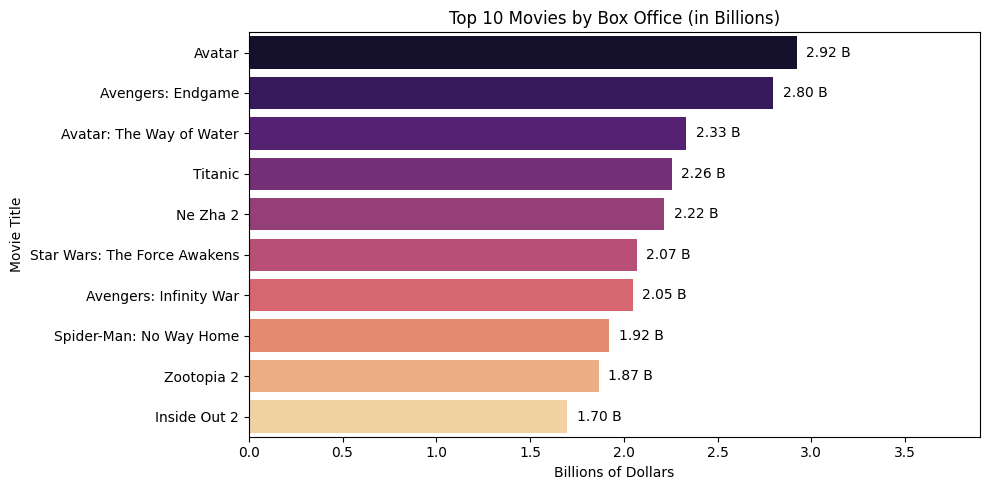

In [ ]:
import io
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab raw table from the response text
tables = pd.read_html(io.StringIO(response.text))
df = tables[0].iloc[:, [2, 3, 4]].copy()
df.columns = ['Title', 'Worldwide_Gross', 'Year']

# 2. Extract ONLY numbers (strips away $, letters, commas)
df['Clean_Number'] = df['Worldwide_Gross'].astype(str).apply(lambda x: re.sub(r'[^\d]', '', x))

# 3. Convert to Billions
df['Gross_in_Billions'] = df['Clean_Number'].astype(float) / 1000000000

# 4. Filter top 10 movies
top_10 = df.head(10)

# 5. Plot the bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10, x='Gross_in_Billions', y='Title', palette='magma')

plt.title('Top 10 Movies by Box Office (in Billions)')
plt.xlabel('Billions of Dollars')
plt.ylabel('Movie Title')

# Add simple number label to each bar
for index, value in enumerate(top_10['Gross_in_Billions']):
    plt.text(value + 0.05, index, f'{value:.2f} B', va='center')

plt.xlim(0, 3.9)
plt.tight_layout()
plt.show()